# IMPORT LIBRARIES AND LOAD DATA

In [ ]:
#Import libraries and load data
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from category_encoders.target_encoder import TargetEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler


transactions = pd.read_csv('trans_labelled_clean.csv')
cards = pd.read_csv('cards_data_south_africa.csv')
users = pd.read_csv('user_data_south_africa.csv')

In [ ]:
trans_merged = pd.merge(transactions, cards, left_on='card_id', right_on='id')
trans_merged = pd.merge(trans_merged, users, left_on='client_id_x', right_on='id')
trans_merged = trans_merged.drop(columns=['id_y', 'client_id_y', 'id'])
trans_merged = trans_merged.rename(columns={
    'id_x': 'id',
    'client_id_x': 'user_id',
})
trans_merged['is_negative_amount'] = trans_merged['amount'] < 0
trans_merged['abs_amount'] = trans_merged['amount'].abs()
trans_merged['is_negative_amount'] = trans_merged['is_negative_amount'].astype(int)
trans_merged['is_fraud'] = trans_merged['is_fraud'].astype(int)

In [ ]:
#Absolute amount
trans_merged['is_negative_amount'] = trans_merged['amount'] < 0
trans_merged['abs_amount'] = trans_merged['amount'].abs()

In [ ]:
trans_merged['is_negative_amount'] = trans_merged['is_negative_amount'].astype(int)

# Time-Based Features

In [5]:
from datetime import datetime, timedelta


trans_merged["date"] = pd.to_datetime(trans_merged["date"])
trans_merged = trans_merged.sort_values(['user_id', 'date']).reset_index(drop=True)
trans_merged["day_of_week"] = trans_merged["date"].dt.dayofweek
trans_merged["trans_hour"] = trans_merged["date"].dt.hour
trans_merged["trans_weekend"] = trans_merged["day_of_week"].isin([5, 6]).astype(int)
trans_merged["trans_day"] = trans_merged["date"].dt.day
trans_merged["trans_month"] = trans_merged["date"].dt.month
trans_merged["trans_year"] = trans_merged["date"].dt.year

In [6]:
'''def get_time_bracket(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
#        return 'Evening'
    else:
        return 'Night'

trans_merged['time_of_day'] = trans_merged['trans_hour'].apply(get_time_bracket)
trans_merged = pd.get_dummies(trans_merged, columns=['time_of_day'], prefix='tod')'''

"def get_time_bracket(hour):\n    if 5 <= hour < 12:\n        return 'Morning'\n    elif 12 <= hour < 17:\n        return 'Afternoon'\n    elif 17 <= hour < 21:\n#        return 'Evening'\n    else:\n        return 'Night'\n\ntrans_merged['time_of_day'] = trans_merged['trans_hour'].apply(get_time_bracket)\ntrans_merged = pd.get_dummies(trans_merged, columns=['time_of_day'], prefix='tod')"

In [7]:
'''trans_merged['time_since_last_tx_user'] = trans_merged.groupby('user_id')['date'].diff().dt.total_seconds() / 60  # in minutes
trans_merged['time_since_last_tx_user'].fillna(-1, inplace=True)  # -1 for first transaction

trans_merged['time_since_last_tx_card'] = trans_merged.groupby('card_id')['date'].diff().dt.total_seconds() / 60
trans_merged['time_since_last_tx_card'].fillna(-1, inplace=True)

trans_merged['is_rapid_transaction_user'] = (trans_merged['time_since_last_tx_user'] < 5).astype(int)  # less than 5 minutes
trans_merged['is_rapid_transaction_card'] = (trans_merged['time_since_last_tx_card'] < 2).astype(int)  # less than 2 minutes'''

"trans_merged['time_since_last_tx_user'] = trans_merged.groupby('user_id')['date'].diff().dt.total_seconds() / 60  # in minutes\ntrans_merged['time_since_last_tx_user'].fillna(-1, inplace=True)  # -1 for first transaction\n\ntrans_merged['time_since_last_tx_card'] = trans_merged.groupby('card_id')['date'].diff().dt.total_seconds() / 60\ntrans_merged['time_since_last_tx_card'].fillna(-1, inplace=True)\n\ntrans_merged['is_rapid_transaction_user'] = (trans_merged['time_since_last_tx_user'] < 5).astype(int)  # less than 5 minutes\ntrans_merged['is_rapid_transaction_card'] = (trans_merged['time_since_last_tx_card'] < 2).astype(int)  # less than 2 minutes"

# Ouliers and Z-Scores

In [8]:
trans_merged['date'] = pd.to_datetime(trans_merged['date'])
trans_merged = trans_merged.sort_values('date').reset_index(drop=True)

def iqr_outlier_mask(s: pd.Series, k: float = 1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound = q1 - k * iqr
    upper_bound = q3 + k * iqr
    return (s < lower_bound) | (s > upper_bound), lower_bound, upper_bound

mask_iqr, lower_iqr, upper_iqr = iqr_outlier_mask(trans_merged['abs_amount'], k=1.5)
df_iqr_outliers = trans_merged.loc[mask_iqr, ["abs_amount"]]
df_iqr_outliers.head(40).sort_values(by='abs_amount')

,abs_amount
785,2880.00
852,3002.40
450,3054.78
944,3133.62
354,3192.84
699,3234.96
832,3311.64
224,3600.00
180,3739.32
278,3768.48


In [9]:
def zscore_outlier_mask(s: pd.Series, threshold: float = 3.5):
    z = (s - s.mean()) / s.std()
    mask = z.abs() > threshold
    return mask, z

mask_z, z = zscore_outlier_mask(trans_merged['abs_amount'], threshold=3.0)
df_z_outliers = trans_merged.loc[mask_z, ["abs_amount"]]
df_z_outliers.head(30).sort_values(by='abs_amount')

,abs_amount
1374,5038.56
714,5153.58
1811,5497.74
971,5598.00
1803,5724.00
229,5778.00
857,5958.00
1256,5970.78
646,6096.60
331,6156.00


In [10]:
trans_merged['is_high_amount'] = mask_iqr.astype(int)

In [11]:
trans_merged['is_zscore_outlier'] = mask_z.astype(int)

In [12]:
trans_merged['monthly_income'] = trans_merged['yearly_income'] / 12
trans_merged["amt_to_income_ratio"] = (trans_merged["abs_amount"] / trans_merged["yearly_income"]) * 100

# Time Window Features

In [13]:
def time_window_features(trans_merged, key, amount_col='abs_amount', ts_col='date'):
    trans_merged = trans_merged.sort_values([key, ts_col])
    g = trans_merged.groupby(key, group_keys=False)

    # Past 24 hours
    roll_24h_count = (g.rolling('24h', on=ts_col)[amount_col].count().shift(1).values)
    roll_24h_sum   = (g.rolling('24h', on=ts_col)[amount_col].sum().shift(1).values)

    # Past 7 days
    roll_7d_count = (g.rolling('7d', on=ts_col)[amount_col].count().shift(1).values)
    roll_7d_sum   = (g.rolling('7d', on=ts_col)[amount_col].sum().shift(1).values)

    return (roll_24h_count, roll_24h_sum, roll_7d_count, roll_7d_sum)

(
    trans_merged['user_txn_count_24h'],
    trans_merged['user_amt_sum_24h'],
    trans_merged['user_txn_count_7d'],
    trans_merged['user_amt_sum_7d'],
) = time_window_features(trans_merged, key='user_id')
(
    trans_merged['merchant_txn_count_24h'],
    trans_merged['merchant_amt_sum_24h'],
    trans_merged['merchant_txn_count_7d'],
    trans_merged['merchant_amt_sum_7d'],
) = time_window_features(trans_merged, key='merchant_id')

(
    trans_merged['city_txn_count_24h'],
    trans_merged['city_amt_sum_24h'],
    trans_merged['city_txn_count_7d'],
    trans_merged['city_amt_sum_7d'],
) = time_window_features(trans_merged, key='merchant_city')

In [14]:
trans_merged['user_mcc_seen_before'] = (
    trans_merged.sort_values(['user_id', 'date'])
      .groupby(['user_id', 'mcc'])
      .cumcount()
)

trans_merged['is_first_time_user_mcc'] = (trans_merged['user_mcc_seen_before'] == 0).astype(int)

In [15]:
#by merchant
trans_merged['user_merchant_seen_before'] = trans_merged.groupby(['user_id','merchant_id']).cumcount()
trans_merged['is_first_time_user_merchant'] = (trans_merged['user_merchant_seen_before'] == 0).astype(int)

#by city
trans_merged['user_city_seen_before'] = trans_merged.groupby(['user_id','merchant_city']).cumcount()
trans_merged['is_first_time_user_city'] = (trans_merged['user_city_seen_before'] == 0).astype(int)

#by hour
trans_merged['user_hour_seen_before'] = trans_merged.groupby(['user_id','trans_hour']).cumcount()
trans_merged['is_first_time_user_hour'] = (trans_merged['user_hour_seen_before'] == 0).astype(int)

# Geographical features

In [16]:
trans_merged['user_city'] = trans_merged['address'].str.split(',').str[1].str.strip()

In [17]:
city_to_region = {
    "cape town": "Western Cape",
    "pretoria": "Gauteng",
    "johannesburg": "Gauteng",
    "durban": "KwaZulu-Natal",
    "pietermaritzburg": "KwaZulu-Natal",
    "gqeberha": "Eastern Cape",
    "east london": "Eastern Cape",
    "bloemfontein": "Free State",
}

# Normalization
def normalize_city(s):
    if pd.isna(s): return None
    return (str(s).strip().lower()
            .replace('.', '')
            .replace('-', ' ')
            .replace(',', ''))

# Apply
trans_merged['city_norm'] = trans_merged['user_city'].map(normalize_city)
trans_merged['user_region'] = trans_merged['city_norm'].map(city_to_region).fillna("unknown")

In [18]:
trans_merged['user_region'] = trans_merged['user_region'].map(normalize_city)

In [19]:
trans_merged['is_far_from_home'] = (
    (trans_merged['use_chip'] != 'online transaction') &
    (trans_merged['user_region'] != trans_merged['merchant_state'])
).astype(int)

In [20]:
trans_merged['is_retired'] = (trans_merged['current_age'] > trans_merged['retirement_age']).astype(int)

# Missing features

In [21]:
trans_merged = trans_merged.sort_values("date")

user_stats = (
    trans_merged.groupby("user_id")["abs_amount"]
      .expanding()
      .agg(["mean", "std"])
      .shift(1)
      .reset_index(level=0, drop=True)
)

trans_merged["z_amount_user"] = (
    (trans_merged["abs_amount"] - user_stats["mean"]) /
    (user_stats["std"].fillna(0) + 1e-6)
)


In [22]:
user_median = (
    trans_merged.groupby("user_id")["abs_amount"]
      .expanding()
      .median()
      .shift(1)
      .reset_index(level=0, drop=True)
)

trans_merged["amount_user_median_ratio"] = trans_merged["abs_amount"] / (user_median + 1e-6)


In [23]:
user_hour_mode = (
    trans_merged.groupby("user_id")["trans_hour"]
      .expanding()
      .apply(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
      .shift(1)
      .reset_index(level=0, drop=True)
)

trans_merged["hour_deviation_user"] = abs(trans_merged["trans_hour"] - user_hour_mode)

In [24]:
#trans_merged = trans_merged.set_index("date")

#trans_merged["user_txn_10m"] = (
#    trans_merged.groupby("user_id")
#      .rolling("10min")
#      .count()
#      .shift(1)
#      .reset_index(level=0, drop=True)
#)


In [25]:
# Ensure sorted and datetime index
'''trans_merged = trans_merged.sort_values("date")

unique_merchants_1h = (
    trans_merged
    .groupby("user_id", group_keys=False)
    .apply(
        lambda g: (
            g.set_index("date")["merchant_id"]
             .rolling("1h")
             .nunique()
             .shift(1)
        )
    )
)

trans_merged["unique_merchants_1h"] = unique_merchants_1h.values
trans_merged["unique_merchants_1h"] = trans_merged["unique_merchants_1h"].fillna(0)'''

'trans_merged = trans_merged.sort_values("date")\n\nunique_merchants_1h = (\n    trans_merged\n    .groupby("user_id", group_keys=False)\n    .apply(\n        lambda g: (\n            g.set_index("date")["merchant_id"]\n             .rolling("1h")\n             .nunique()\n             .shift(1)\n        )\n    )\n)\n\ntrans_merged["unique_merchants_1h"] = unique_merchants_1h.values\ntrans_merged["unique_merchants_1h"] = trans_merged["unique_merchants_1h"].fillna(0)'

In [26]:
trans_merged.head()

,id,date,user_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,user_hour_seen_before,is_first_time_user_hour,user_city,city_norm,user_region,is_far_from_home,is_retired,z_amount_user,amount_user_median_ratio,hour_deviation_user
0,15626211,2022-01-01 00:00:10,24,2827,47.16,chip transaction,14528,polokwane,limpopo,700.0,...,0,1,Cape Town,cape town,western cape,1,0,-0.621845,0.103516,5.0
1,17529598,2022-01-01 00:00:21,1326,5561,123.12,chip transaction,94123,east london,eastern cape,5200.0,...,0,1,Pretoria,pretoria,gauteng,1,0,-1.110946,0.091505,3.0
2,15750655,2022-01-01 00:00:21,696,4207,25.56,swipe transaction,46284,bloemfontein,free state,9300.0,...,0,1,East London,east london,eastern cape,1,1,-0.590319,0.061472,17.0
3,18999635,2022-01-01 00:00:29,1640,4967,527.40,swipe transaction,81536,port elizabeth,eastern cape,6000.0,...,0,1,Pretoria,pretoria,gauteng,1,0,-0.629265,0.379878,1.0
4,18403665,2022-01-01 00:01:10,185,4046,55.44,chip transaction,22204,kimberley,northern cape,8300.0,...,0,1,Bloemfontein,bloemfontein,free state,1,0,-0.705288,0.122222,17.0


In [27]:
trans_merged = trans_merged.reset_index(drop=False)
trans_merged["time_diff"] = trans_merged.groupby("user_id")["date"].diff().dt.seconds

trans_merged["avg_gap_last3"] = (
    trans_merged.groupby("user_id")["time_diff"]
      .rolling(3)
      .mean()
      .shift(1)
      .reset_index(level=0, drop=True)
)


MemoryError: Unable to allocate 2.12 GiB for an array with shape (33, 8615533) and data type int64

In [ ]:
# trans_merged = trans_merged.reset_index(drop=False)
# trans_merged['date'] = pd.to_datetime(trans_merged['date'])
# trans_merged = trans_merged.sort_values(["merchant_id", "date"])

#   merchant_fraud_rate_7d = (
#     trans_merged
#        .set_index("date")
#        .groupby("merchant_id")["is_fraud"]
#        .rolling("7D")
#        .mean()
#        .shift(1))

# merchant_fraud_rate_7d = merchant_fraud_rate_7d.reset_index(level=0, drop=True)
# trans_merged["merchant_fraud_rate_7d"] = merchant_fraud_rate_7d.values


In [ ]:
#trans_merged["mcc_fraud_rate_30d"] = (
#    trans_merged.groupby("mcc")["is_fraud"]
#      .rolling("30d")
#      .mean()
#      .shift(1)
#      .reset_index(level=0, drop=True)
#)

In [28]:
user_hist = (
    trans_merged.groupby("user_id")["is_fraud"]
      .expanding()
      .mean()
      .shift(1)
      .reset_index(level=0, drop=True)
)

trans_merged["user_hist_fraud_rate"] = user_hist


In [32]:
trans_merged = trans_merged.sort_values(["user_id", "date"])
last_fraud = (
    trans_merged[trans_merged["is_fraud"] == 1]
      .groupby("user_id")["date"]
      .shift(1)
)

trans_merged["days_since_last_fraud_user"] = (
    (trans_merged["date"] - last_fraud).dt.days
)

In [33]:
trans_merged[["user_id", "date","is_fraud","days_since_last_fraud_user"]].sample(50)

,user_id,date,is_fraud,days_since_last_fraud_user
5527294,1224,2023-12-03 16:26:36,0,NaN
652039,1581,2022-03-21 10:03:41,0,NaN
2002236,1221,2022-09-11 10:27:35,0,NaN
5932343,457,2024-01-23 01:39:18,0,NaN
3525585,1523,2023-03-21 12:08:19,0,NaN
173686,1622,2022-01-21 08:54:48,0,NaN
7194307,408,2024-07-02 15:25:26,0,NaN
2338666,1555,2022-10-22 18:29:33,0,NaN
2949972,1730,2023-01-10 03:42:44,0,NaN
7816652,602,2024-09-19 12:18:43,0,NaN


In [34]:
one_user = trans_merged["user_id"].iloc[0]
trans_merged[trans_merged["user_id"] == one_user][["date","is_fraud","days_since_last_fraud_user"]].head(50)

,date,is_fraud,days_since_last_fraud_user
293,2022-01-01 00:46:02,0,NaN
1803,2022-01-01 05:02:57,0,NaN
2113,2022-01-01 06:04:41,0,NaN
2747,2022-01-01 07:49:43,0,NaN
4939,2022-01-01 14:07:18,0,NaN
5156,2022-01-01 14:46:33,0,NaN
6362,2022-01-01 18:12:15,0,NaN
6982,2022-01-01 20:00:49,0,NaN
7901,2022-01-01 22:34:05,0,NaN
10216,2022-01-02 05:03:52,0,NaN


In [36]:
trans_merged["days_since_last_fraud_user"].describe()

count    11638.000000
mean        77.131896
std         96.523213
min          0.000000
25%         17.000000
50%         45.000000
75%         99.000000
max       1039.000000
Name: days_since_last_fraud_user, dtype: float64

In [ ]:
df = trans_merged.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["user_id", "date"])

cols_to_show = ["user_id", "date", "id", "amount", "is_fraud", "days_since_last_fraud_user"]

for user_id, grp in df[cols_to_show].groupby("user_id"):
    print(f"\n========== User: {user_id} ==========")
    print(grp.sort_values("date").to_string(index=False))


In [ ]:
trans_merged["hour_sin"] = np.sin(2 * np.pi * trans_merged["trans_hour"] / 24)
trans_merged["hour_cos"] = np.cos(2 * np.pi * trans_merged["trans_hour"] / 24)

In [ ]:
trans_merged.isna().sum()

index                         0
id                            0
date                          0
user_id                       0
card_id                       0
                             ..
avg_gap_last3                 0
user_hist_fraud_rate          0
days_since_last_fraud_user    0
hour_sin                      0
hour_cos                      0
Length: 89, dtype: int64

In [ ]:
features_no_history = [
    'z_amount_user', 'amount_user_median_ratio',
    'hour_deviation_user', 'time_diff',
    'avg_gap_last3', 'user_hist_fraud_rate', 'days_since_last_fraud_user']

trans_merged[features_no_history] = trans_merged[features_no_history].fillna(0)
trans_merged.isna().sum().sort_values(ascending=False).head(70)

merchant_amt_sum_7d        1
user_amt_sum_24h           1
user_txn_count_24h         1
city_txn_count_7d          1
city_amt_sum_7d            1
                          ..
user_city_seen_before      0
is_first_time_user_city    0
user_hour_seen_before      0
is_first_time_user_hour    0
user_city                  0
Length: 70, dtype: int64

# Behavioral features

In [32]:
trans_merged['is_unusual_brand_for_user'] = (
    trans_merged.groupby(['user_id', 'card_brand'])
      .cumcount()
      .eq(0)
      .astype(int)
)
user_txn_counts = trans_merged.groupby('user_id').cumcount()

trans_merged.loc[user_txn_counts < 3, 'is_unusual_brand_for_user'] = 0

In [ ]:
# Ensure datetime
'''trans_merged["date"] = pd.to_datetime(trans_merged["date"], errors="coerce")

def clean_error(e):
    try:
        if pd.isna(e):
            return "noerrors"
        e = str(e).lower().strip()
        e = e.replace(" ", "").replace("__", "_")
        return e
    except:
        return "noerrors"

# Apply row-by-row (safe, avoids memory blowup)
trans_merged["errors_clean"] = trans_merged["errors"].apply(clean_error)

# Convert to list safely
trans_merged["error_list"] = trans_merged["errors_clean"].apply(lambda x: x.split(","))

# Flag errors
trans_merged["has_error"] = (trans_merged["errors_clean"] != "noerrors").astype(int)'''

In [34]:
features_no_history = [
    'is_high_amount', 'is_zscore_outlier', 'monthly_income',
    'amt_to_income_ratio', 'user_txn_count_24h', 'user_amt_sum_24h',
    'user_txn_count_7d', 'user_amt_sum_7d', 'merchant_txn_count_24h',
    'merchant_amt_sum_24h', 'merchant_txn_count_7d', 'merchant_amt_sum_7d',
    'city_txn_count_24h', 'city_amt_sum_24h', 'city_txn_count_7d',
    'city_amt_sum_7d', 'user_mcc_seen_before',
    'is_first_time_user_mcc', 'user_merchant_seen_before',
    'is_first_time_user_merchant', 'user_city_seen_before',
    'is_first_time_user_city', 'user_hour_seen_before',
    'is_first_time_user_hour'
]

trans_merged[features_no_history] = trans_merged[features_no_history].fillna(0)
trans_merged.isna().sum().sort_values(ascending=False).head(40)

index                    0
id                       0
date                     0
user_id                  0
card_id                  0
amount                   0
use_chip                 0
merchant_id              0
merchant_city            0
merchant_state           0
zip                      0
mcc                      0
errors                   0
is_fraud                 0
description              0
card_brand               0
card_type                0
card_number              0
expires                  0
cvv                      0
has_chip                 0
num_cards_issued         0
credit_limit             0
acct_open_date           0
year_pin_last_changed    0
card_on_dark_web         0
current_age              0
retirement_age           0
birth_year               0
birth_month              0
gender                   0
address                  0
per_capita_income        0
yearly_income            0
total_debt               0
credit_score             0
num_credit_cards         0
i

In [36]:
cols_to_drop = [
    'card_number', 'address', 'zip', 'description', 'merchant_state',
    'cvv', 'expires', 'birth_year', 'birth_month', 'retirement_age', 
    'acct_open_date', 'year_pin_last_changed', 'card_on_dark_web', 'yearly_income', 'total_debt', 'credit_score', 'user_city'
]

trans_merged = trans_merged.drop(columns=cols_to_drop)

In [ ]:
'''windows = {
    "1m": "1min",
    "5m": "5min",
    "1h": "1h",
    "24h": "24h"
}

for label, win in windows.items():
    s = (
        trans_merged
        .groupby("user_id")
        .rolling(win, on="date")["has_error"]
        .sum()
        .shift(1)                                # prevent leakage
        .reset_index(level=0, drop=True)         # drop group key; keep positional order
    )

trans_merged[f"errors_last_{label}"] = s.to_numpy()'''

In [ ]:
'''error_keywords = {
    "insufficient_balance": "insufficientbalance",
    "bad_pin": "badpin",
    "technical_glitch": "technicalglitch",
    "bad_card_number": "badcardnumber",
    "bad_expiration": "badexpiration",
    "bad_cvv": "badcvv",
    "bad_zipcode": "badzipcode"
}

for feature, keyword in error_keywords.items():
    trans_merged[f"{feature}_flag"] = trans_merged["errors"].fillna("").str.contains(keyword, case=False).astype(int)'''


In [ ]:
'''user_seen_errors = {}

def is_new_error(user, errors):
    if user not in user_seen_errors:
        user_seen_errors[user] = set()

    flat_err = set(errors) if errors != ["NoErrors"] else set()

    is_new = int(len(flat_err - user_seen_errors[user]) > 0)

    # update history
    user_seen_errors[user].update(flat_err)
    return is_new

trans_merged["is_new_error_code"] = trans_merged.apply(
    lambda row: is_new_error(row["user_id"], row["error_list"]),
    axis=1)'''

In [ ]:
'''trans_merged = trans_merged.sort_values(["user_id", "date"])

trans_merged["is_success"] = (trans_merged["errors"] == "No Errors").astype(int)
trans_merged["seg"] = trans_merged.groupby("user_id")["is_success"].cumsum()

trans_merged["errors_before_success"] = (
    trans_merged
    .loc[trans_merged["has_error"] == 1]
    .groupby(["user_id", "seg"])
    .cumcount()
)

trans_merged["errors_before_success"] = (
    trans_merged["errors_before_success"].fillna(0).astype(int)'''
)

# Machine Learning

In [43]:
trans_merged.columns.tolist()

['index',
 'id',
 'date',
 'user_id',
 'card_id',
 'amount',
 'use_chip',
 'merchant_id',
 'merchant_city',
 'mcc',
 'errors',
 'is_fraud',
 'card_brand',
 'card_type',
 'has_chip',
 'num_cards_issued',
 'credit_limit',
 'current_age',
 'gender',
 'per_capita_income',
 'num_credit_cards',
 'is_negative_amount',
 'abs_amount',
 'day_of_week',
 'trans_hour',
 'trans_weekend',
 'trans_day',
 'trans_month',
 'trans_year',
 'tod_Afternoon',
 'tod_Evening',
 'tod_Morning',
 'tod_Night',
 'time_since_last_tx_user',
 'time_since_last_tx_card',
 'is_rapid_transaction_user',
 'is_rapid_transaction_card',
 'is_high_amount',
 'is_zscore_outlier',
 'monthly_income',
 'amt_to_income_ratio',
 'user_txn_count_24h',
 'user_amt_sum_24h',
 'user_txn_count_7d',
 'user_amt_sum_7d',
 'merchant_txn_count_24h',
 'merchant_amt_sum_24h',
 'merchant_txn_count_7d',
 'merchant_amt_sum_7d',
 'city_txn_count_24h',
 'city_amt_sum_24h',
 'city_txn_count_7d',
 'city_amt_sum_7d',
 'user_mcc_seen_before',
 'is_first_time

In [37]:
cols_to_remove = [
    'gender', 'errors', 'id', 'user_id', 'card_id', 'amount', 'merchant_id',
    'mcc', 'credit_limit', 'user_region', 'per_capita_income',
    'num_credit_cards', 'merchant_city', 'trans_day', 'trans_month','trans_year', 'tod_Afternoon', 'tod_Evening', 'tod_Morning', 'tod_Night',
    'is_retired', 'num_cards_issued', 'is_rapid_transaction_card', 'city_txn_count_7d', 'is_high_amount', 'is_first_time_user_hour',
    'is_rapid_transaction_user', 'error_list'
]

trans_final = trans_merged.drop(columns=cols_to_remove, errors='ignore')
trans_final.shape


(8615533, 46)

In [50]:
trans_final.head()

,index,date,use_chip,is_fraud,card_brand,card_type,has_chip,current_age,is_negative_amount,abs_amount,...,errors_before_success,z_amount_user,amount_user_median_ratio,hour_deviation_user,time_diff,avg_gap_last3,user_hist_fraud_rate,days_since_last_fraud_user,hour_sin,hour_cos
0,0,2022-01-01 00:00:10,chip transaction,0,Visa,Debit,YES,48,0,47.16,...,0,-0.621845,0.103516,5.0,0.0,25061.666667,0.007022,0.0,0.0,1.0
1,1,2022-01-01 00:00:21,chip transaction,0,Visa,Debit,YES,52,0,123.12,...,0,-1.110946,0.091505,3.0,0.0,7943.000000,0.001699,0.0,0.0,1.0
2,2,2022-01-01 00:00:21,swipe transaction,0,Visa,Debit,NO,74,0,25.56,...,0,-0.590319,0.061472,17.0,0.0,23520.000000,0.005683,0.0,0.0,1.0
3,3,2022-01-01 00:00:29,swipe transaction,0,Visa,Debit,YES,67,0,527.40,...,0,-0.629265,0.379878,1.0,0.0,13399.666667,0.001508,0.0,0.0,1.0
4,4,2022-01-01 00:01:10,chip transaction,0,Visa,Debit,YES,47,0,55.44,...,0,-0.705288,0.122222,17.0,0.0,47331.333333,0.005927,0.0,0.0,1.0


In [39]:
#cols_to_remove = ['expires', 'cvv', 'card_on_dark_web', 'current_age',
#    'retirement_age', 'birth_year', 'birth_month', 'address', 'per_capita_income', 'yearly_income', 'total_debt',
#    'num_credit_cards', 'merchant_city', 'description', 'acct_open_date',
#    'user_city'
#]

#trans_merged.drop(columns=cols_to_remove, inplace=True)
#trans_merged.shape

In [38]:
trans_merged.columns

Index(['index', 'id', 'date', 'user_id', 'card_id', 'amount', 'use_chip',
       'merchant_id', 'merchant_city', 'mcc', 'errors', 'is_fraud',
       'card_brand', 'card_type', 'has_chip', 'num_cards_issued',
       'credit_limit', 'current_age', 'gender', 'per_capita_income',
       'num_credit_cards', 'is_negative_amount', 'abs_amount', 'day_of_week',
       'trans_hour', 'trans_weekend', 'trans_day', 'trans_month', 'trans_year',
       'is_high_amount', 'is_zscore_outlier', 'monthly_income',
       'amt_to_income_ratio', 'user_txn_count_24h', 'user_amt_sum_24h',
       'user_txn_count_7d', 'user_amt_sum_7d', 'merchant_txn_count_24h',
       'merchant_amt_sum_24h', 'merchant_txn_count_7d', 'merchant_amt_sum_7d',
       'city_txn_count_24h', 'city_amt_sum_24h', 'city_txn_count_7d',
       'city_amt_sum_7d', 'user_mcc_seen_before', 'is_first_time_user_mcc',
       'user_merchant_seen_before', 'is_first_time_user_merchant',
       'user_city_seen_before', 'is_first_time_user_city',
     

# Encoding

In [40]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['use_chip', 'card_brand', 'card_type', 'has_chip']

for col in label_cols:
    le = LabelEncoder()
    trans_final[col] = le.fit_transform(trans_final[col])

trans_final.head(20)

,index,date,use_chip,is_fraud,card_brand,card_type,has_chip,current_age,is_negative_amount,abs_amount,...,z_amount_user,amount_user_median_ratio,hour_deviation_user,time_diff,avg_gap_last3,user_hist_fraud_rate,days_since_last_fraud_user,hour_sin,hour_cos,is_unusual_brand_for_user
0,0,2022-01-01 00:00:10,0,0,3,1,1,48,0,47.16,...,-0.621845,0.103516,5.0,0.0,25061.666667,0.007022,0.0,0.0,1.0,0
1,1,2022-01-01 00:00:21,0,0,3,1,1,52,0,123.12,...,-1.110946,0.091505,3.0,0.0,7943.000000,0.001699,0.0,0.0,1.0,0
2,2,2022-01-01 00:00:21,2,0,3,1,0,74,0,25.56,...,-0.590319,0.061472,17.0,0.0,23520.000000,0.005683,0.0,0.0,1.0,0
3,3,2022-01-01 00:00:29,2,0,3,1,1,67,0,527.40,...,-0.629265,0.379878,1.0,0.0,13399.666667,0.001508,0.0,0.0,1.0,0
4,4,2022-01-01 00:01:10,0,0,3,1,1,47,0,55.44,...,-0.705288,0.122222,17.0,0.0,47331.333333,0.005927,0.0,0.0,1.0,0
5,5,2022-01-01 00:01:16,0,0,2,2,1,39,0,269.82,...,-0.567015,0.348200,1.0,0.0,39280.333333,0.006447,0.0,0.0,1.0,0
6,6,2022-01-01 00:01:21,0,0,2,1,1,33,0,700.02,...,-0.159768,1.424542,11.0,0.0,12358.333333,0.000213,0.0,0.0,1.0,0
7,7,2022-01-01 00:01:32,2,0,1,0,1,55,0,641.16,...,-0.161663,0.846885,0.0,0.0,15067.666667,0.002106,0.0,0.0,1.0,0
8,8,2022-01-01 00:01:32,0,0,2,0,1,56,0,90.18,...,-1.081149,0.089995,11.0,0.0,27221.333333,0.001721,0.0,0.0,1.0,0
9,9,2022-01-01 00:01:41,0,0,3,0,1,61,0,1501.02,...,-0.051790,1.613427,16.0,0.0,37613.333333,0.007853,0.0,0.0,1.0,0


In [58]:
trans_merged.dtypes

index                                  int64
date                          datetime64[ns]
use_chip                               int64
merchant_city                         object
merchant_state                        object
                                   ...      
user_hist_fraud_rate                 float64
days_since_last_fraud_user           float64
hour_sin                             float64
hour_cos                             float64
month_block                           object
Length: 70, dtype: object

In [42]:
trans_final = trans_final.sort_values("date")

trans_final["month_block"] = trans_final["date"].dt.to_period("M").astype(str)

from sklearn.model_selection import train_test_split

train_blocks, test_blocks = train_test_split(
    trans_final["month_block"].unique(),
    test_size=0.2,
    random_state=42,
    stratify=trans_final.groupby("month_block")["is_fraud"].sum() > 0
)

train_df = trans_final[trans_final["month_block"].isin(train_blocks)].sort_values("date")
test_df = trans_final[trans_final["month_block"].isin(test_blocks)].sort_values("date")

In [79]:
# target column
target_col = "is_fraud"

# TRAIN
y_train = train_df[target_col].copy()
X_train = train_df.drop(columns=[target_col])

# TEST
y_test = test_df[target_col].copy()
X_test = test_df.drop(columns=[target_col])
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6700808, 46)
y_train shape: (6700808,)
X_test shape: (1914725, 46)
y_test shape: (1914725,)


In [ ]:
'''# 1) Build month blocks and sort chronologically
trans_final = trans_final.sort_values("date").copy()
trans_final["month_block"] = trans_final["date"].dt.to_period("M").astype(str)

# 2) Chronological split: last 20% months = test
months = (
    trans_final["month_block"]
    .drop_duplicates()
    .sort_values()
    .tolist())
n_test_months = max(1, int(round(0.2 * len(months))))
test_months = months[-n_test_months:]     # most recent months ONLY
train_months = months[:-n_test_months]

train_df = trans_final[trans_final["month_block"].isin(train_blocks)].sort_values("date")
test_df  = trans_final[trans_final["month_block"].isin(test_blocks)].sort_values("date")

target_col = "is_fraud"
y_train = train_df[target_col].copy()
X_train = train_df.drop(columns=[target_col])
y_test  = test_df[target_col].copy()
X_test  = test_df.drop(columns=[target_col])'''


In [80]:
cols_to_remove = ['index', 'month_block', 'is_unusual_brand_for_user', 'date']


X_test.drop(columns=cols_to_remove, inplace=True)
X_train.drop(columns=cols_to_remove, inplace=True)
X_train.head()

,use_chip,card_brand,card_type,has_chip,current_age,is_negative_amount,abs_amount,day_of_week,trans_hour,trans_weekend,...,is_far_from_home,z_amount_user,amount_user_median_ratio,hour_deviation_user,time_diff,avg_gap_last3,user_hist_fraud_rate,days_since_last_fraud_user,hour_sin,hour_cos
0,0,3,1,1,48,0,47.16,5,0,1,...,1,-0.621845,0.103516,5.0,0.0,25061.666667,0.007022,0.0,0.0,1.0
1,0,3,1,1,52,0,123.12,5,0,1,...,1,-1.110946,0.091505,3.0,0.0,7943.000000,0.001699,0.0,0.0,1.0
2,2,3,1,0,74,0,25.56,5,0,1,...,1,-0.590319,0.061472,17.0,0.0,23520.000000,0.005683,0.0,0.0,1.0
3,2,3,1,1,67,0,527.40,5,0,1,...,1,-0.629265,0.379878,1.0,0.0,13399.666667,0.001508,0.0,0.0,1.0
4,0,3,1,1,47,0,55.44,5,0,1,...,1,-0.705288,0.122222,17.0,0.0,47331.333333,0.005927,0.0,0.0,1.0


In [ ]:
'''cols_to_remove = ['date']


X_test.drop(columns=cols_to_remove, inplace=True)
X_train.drop(columns=cols_to_remove, inplace=True)
X_train.head()'''

,use_chip,card_brand,card_type,has_chip,current_age,is_negative_amount,abs_amount,day_of_week,trans_hour,trans_weekend,...,z_amount_user,amount_user_median_ratio,hour_deviation_user,time_diff,avg_gap_last3,user_hist_fraud_rate,days_since_last_fraud_user,hour_sin,hour_cos,is_unusual_brand_for_user
0,0,3,1,1,48,0,47.16,5,0,1,...,-0.621845,0.103516,5.0,0.0,25061.666667,0.007022,0.0,0.0,1.0,0
1,0,3,1,1,52,0,123.12,5,0,1,...,-1.110946,0.091505,3.0,0.0,7943.000000,0.001699,0.0,0.0,1.0,0
2,2,3,1,0,74,0,25.56,5,0,1,...,-0.590319,0.061472,17.0,0.0,23520.000000,0.005683,0.0,0.0,1.0,0
3,2,3,1,1,67,0,527.40,5,0,1,...,-0.629265,0.379878,1.0,0.0,13399.666667,0.001508,0.0,0.0,1.0,0
4,0,3,1,1,47,0,55.44,5,0,1,...,-0.705288,0.122222,17.0,0.0,47331.333333,0.005927,0.0,0.0,1.0,0


In [ ]:
'''cols_to_remove = ['is_unusual_brand_for_user']


X_test.drop(columns=cols_to_remove, inplace=True)
X_train.drop(columns=cols_to_remove, inplace=True)
X_train.head()'''

,use_chip,card_brand,card_type,has_chip,current_age,is_negative_amount,abs_amount,day_of_week,trans_hour,trans_weekend,...,is_far_from_home,z_amount_user,amount_user_median_ratio,hour_deviation_user,time_diff,avg_gap_last3,user_hist_fraud_rate,hour_sin,hour_cos,is_unusual_brand_for_user
0,0,3,1,1,48,0,47.16,5,0,1,...,1,-0.621845,0.103516,5.0,0.0,25061.666667,0.007022,0.0,1.0,0
1,0,3,1,1,52,0,123.12,5,0,1,...,1,-1.110946,0.091505,3.0,0.0,7943.000000,0.001699,0.0,1.0,0
2,2,3,1,0,74,0,25.56,5,0,1,...,1,-0.590319,0.061472,17.0,0.0,23520.000000,0.005683,0.0,1.0,0
3,2,3,1,1,67,0,527.40,5,0,1,...,1,-0.629265,0.379878,1.0,0.0,13399.666667,0.001508,0.0,1.0,0
4,0,3,1,1,47,0,55.44,5,0,1,...,1,-0.705288,0.122222,17.0,0.0,47331.333333,0.005927,0.0,1.0,0


In [81]:
from category_encoders import TargetEncoder

cols = ["city_norm"]

tgt_encoder = TargetEncoder(
    cols=cols,
    smoothing=10,
    min_samples_leaf=20
)

X_train_te = tgt_encoder.fit_transform(
    X_train[cols],
    y_train
)

X_test_te = tgt_encoder.transform(X_test[cols])
# Replace columns in original data
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

X_train_enc[cols] = X_train_te
X_test_enc[cols] = X_test_te


In [82]:
from imblearn.under_sampling import RandomUnderSampler

fraud_count = y_train.sum()          # 9951
target_total = 1_200_000
target_nonfraud = target_total - fraud_count

sampling_strategy = fraud_count / target_nonfraud

rus = RandomUnderSampler(
    sampling_strategy=sampling_strategy,
    random_state=42
)

X_train_rus, y_train_rus = rus.fit_resample(X_train_enc, y_train)

print("Before undersample:\n", y_train.value_counts())
print("After undersample:\n", y_train_rus.value_counts())
print("Total rows after:", len(y_train_rus))

Before undersample:
 is_fraud
0    6690857
1       9951
Name: count, dtype: int64
After undersample:
 is_fraud
0    1190049
1       9951
Name: count, dtype: int64
Total rows after: 1200000


In [66]:
X_train_rus.dtypes

use_chip                         int64
card_brand                       int64
card_type                        int64
has_chip                         int64
current_age                      int64
is_negative_amount               int64
abs_amount                     float64
day_of_week                      int32
trans_hour                       int32
trans_weekend                    int64
is_zscore_outlier                int64
monthly_income                 float64
amt_to_income_ratio            float64
user_txn_count_24h             float64
user_amt_sum_24h               float64
user_txn_count_7d              float64
user_amt_sum_7d                float64
merchant_txn_count_24h         float64
merchant_amt_sum_24h           float64
merchant_txn_count_7d          float64
merchant_amt_sum_7d            float64
city_txn_count_24h             float64
city_amt_sum_24h               float64
city_amt_sum_7d                float64
user_mcc_seen_before             int64
is_first_time_user_mcc   

# 1st try

In [83]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

lgbm = LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=127,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    max_bin=500,
)

xgb = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train_rus.value_counts()[0] / y_train_rus.value_counts()[1]),
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
    gamma=1,
    min_child_weight=10, 
    reg_alpha=1.0, 
    reg_lambda=2.0
)

#rf = RandomForestClassifier(
#    n_estimators=150,
#    max_depth=10,
#    class_weight="balanced",
#    random_state=42
#)
base_models = [
    ('lgbm', lgbm),
    ('xgb', xgb),
#    ('rf', rf)
]

meta_learner = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

stacked_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1,
    passthrough=False,
)


In [76]:
X_test.dtypes

use_chip                         int64
card_brand                       int64
card_type                        int64
has_chip                         int64
current_age                      int64
is_negative_amount               int64
abs_amount                     float64
day_of_week                      int32
trans_hour                       int32
trans_weekend                    int64
time_since_last_tx_user        float64
time_since_last_tx_card        float64
is_zscore_outlier                int64
monthly_income                 float64
amt_to_income_ratio            float64
user_txn_count_24h             float64
user_amt_sum_24h               float64
user_txn_count_7d              float64
user_amt_sum_7d                float64
merchant_txn_count_24h         float64
merchant_amt_sum_24h           float64
merchant_txn_count_7d          float64
merchant_amt_sum_7d            float64
city_txn_count_24h             float64
city_amt_sum_24h               float64
city_amt_sum_7d          

In [ ]:
import numpy as np
import xgboost as xgb
import lightgbm as lgb

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import average_precision_score, precision_recall_curve

from imblearn.under_sampling import RandomUnderSampler


def train_fraud_model(
    X_train_fin,
    y_train,
    X_test,
    y_test,
    *,
    use_undersampling=False,
    undersample_ratio=0.15,
    random_state=42
):

    fraud_count = y_train.sum()
    nonfraud_count = len(y_train) - fraud_count
    pos_weight = nonfraud_count / fraud_count

    if use_undersampling:
        rus = RandomUnderSampler(
            sampling_strategy=undersample_ratio,
            random_state=random_state
        )
        X_train_fit, y_train_fit = rus.fit_resample(X_train_fin, y_train)
    else:
        X_train_fit, y_train_fit = X_train_fin, y_train

# XGBoost
    xgb_base = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        learning_rate=0.05,
        n_estimators=800,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=pos_weight,
        random_state=random_state,
        n_jobs=-1
    )

    xgb_param_grid = {
        "max_depth": [5, 6, 7],
        "min_child_weight": [1, 5, 10, 20],
        "gamma": [0, 0.5, 1, 5]
    }

    xgb_search = RandomizedSearchCV(
        xgb_base,
        xgb_param_grid,
        n_iter=20,
        scoring="average_precision",
        cv=3,
        verbose=1,
        random_state=random_state,
        n_jobs=1
    )

    xgb_search.fit(X_train_fit, y_train_fit)
    best_xgb = xgb_search.best_estimator_

# LightGBM
    lgb_base = lgb.LGBMClassifier(
        objective="binary",
        metric="aucpr",
        learning_rate=0.05,
        n_estimators=1200,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight={0: 1, 1: pos_weight},
        random_state=random_state,
        n_jobs=-1
    )

    lgb_param_grid = {
        "num_leaves": [31, 63, 127],
        "min_data_in_leaf": [50, 200, 500, 1000],
        "max_depth": [-1, 6, 8]
    }

    lgb_search = RandomizedSearchCV(
        lgb_base,
        lgb_param_grid,
        n_iter=20,
        scoring="average_precision",
        cv=3,
        verbose=1,
        random_state=random_state,
        n_jobs=1
    )

    lgb_search.fit(X_train_fit, y_train_fit)
    best_lgb = lgb_search.best_estimator_

# RandomForest
    rf = RandomForestClassifier(
        n_estimators=400,
        max_depth=18,
        min_samples_leaf=100,
        max_features="sqrt",
        class_weight={0: 1, 1: pos_weight},
        random_state=random_state,
        n_jobs=-1
    )

    rf.fit(X_train_fit, y_train_fit)

# Stacking
    stack = StackingClassifier(
        estimators=[
            ("xgb", best_xgb),
            ("lgb", best_lgb),
            ("rf", rf)
        ],
        final_estimator=LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            n_jobs=-1
        ),
        stack_method="predict_proba",
        passthrough=False,
        n_jobs=-1
    )

    stack.fit(X_train_fit, y_train_fit)

# Fitting and evaluation

In [84]:
print(y_train_rus.value_counts())

is_fraud
0    1190049
1       9951
Name: count, dtype: int64


In [85]:
from sklearn.calibration import CalibratedClassifierCV

stacked_model.fit(X_train_rus, y_train_rus)
y_pred_proba = stacked_model.predict_proba(X_test_enc)[:, 1]

=== Classification Report (threshold=0.5) ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1911860
           1       0.22      0.98      0.36      2865

    accuracy                           0.99   1914725
   macro avg       0.61      0.99      0.68   1914725
weighted avg       1.00      0.99      1.00   1914725

ROC-AUC: 0.9995
PR-AUC: 0.9720
Confusion Matrix:
 [[1901694   10166]
 [     49    2816]]


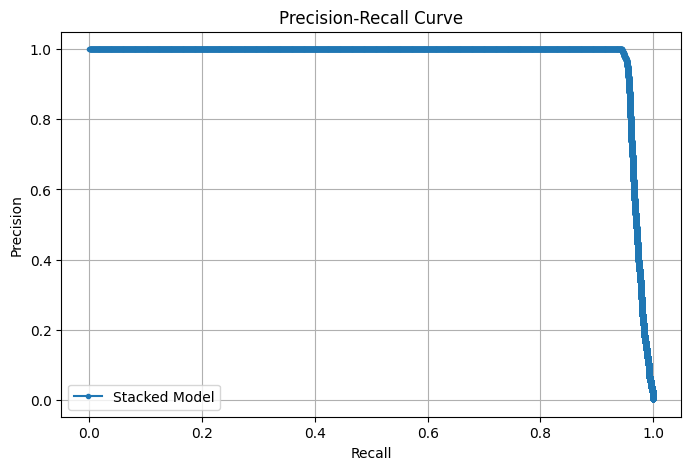

Optimal Threshold for max F1-score: 0.9972
Max F1-score at this threshold: 0.9713
=== Classification Report (optimal threshold) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1911860
           1       1.00      0.94      0.97      2865

    accuracy                           1.00   1914725
   macro avg       1.00      0.97      0.99   1914725
weighted avg       1.00      1.00      1.00   1914725

Confusion Matrix (Optimal Threshold):
 [[1911859       1]
 [    159    2706]]


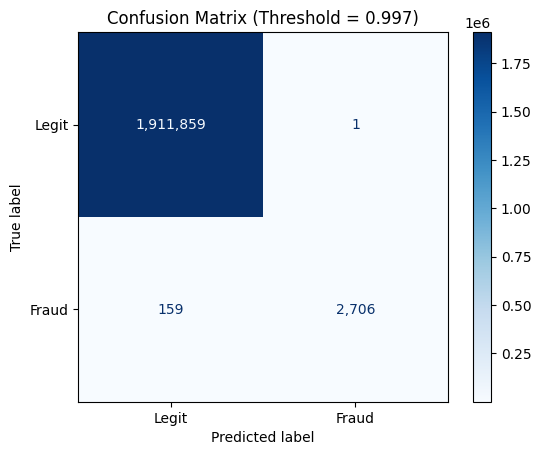

In [86]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    f1_score
)
import matplotlib.pyplot as plt
import numpy as np



# Step 2: Default predictions (threshold 0.5)
y_pred_default = (y_pred_proba >= 0.5).astype(int)


# Step 3: Metrics
print("=== Classification Report (threshold=0.5) ===")
print(classification_report(y_test, y_pred_default))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {roc_auc:.4f}")

pr_auc = average_precision_score(y_test, y_pred_proba)
print(f"PR-AUC: {pr_auc:.4f}")

cm = confusion_matrix(y_test, y_pred_default)
print("Confusion Matrix:\n", cm)


# Step 4: Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
           
plt.figure(figsize=(8,5))
plt.plot(recall, precision, marker='.', label='Stacked Model')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()


# Step 5: Find optimal threshold by maximizing F1-score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)  # avoid division by zero
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Optimal Threshold for max F1-score: {best_threshold:.4f}")
print(f"Max F1-score at this threshold: {best_f1:.4f}")

# Predictions at optimal threshold
y_pred_opt = (y_pred_proba >= best_threshold).astype(int)
print("=== Classification Report (optimal threshold) ===")
print(classification_report(y_test, y_pred_opt))

cm_opt = confusion_matrix(y_test, y_pred_opt)
print("Confusion Matrix (Optimal Threshold):\n", cm_opt)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_opt,
    display_labels=['Legit', 'Fraud']
)

disp.plot(cmap='Blues', values_format=',')
plt.title(f'Confusion Matrix (Threshold = {best_threshold:.3f})')
plt.show()



# Feature Importance from Base Models

For LightGBM

In [73]:
feature_names = X_train_rus.columns
lgbm_model = stacked_model.named_estimators_['lgbm']
xgb_model  = stacked_model.named_estimators_['xgb']

For XGBoost

In [74]:
lgbm_importance = lgbm_model.feature_importances_
xgb_importance = xgb_model.feature_importances_

Weighted Feature Importance Across Base Models

In [75]:
lgbm_norm = lgbm_importance / (lgbm_importance.sum() + 1e-8)
xgb_norm  = xgb_importance  / (xgb_importance.sum()  + 1e-8)

combined_importance = (lgbm_norm + xgb_norm) / 2

In [76]:
importance_df = pd.DataFrame({
    'feature': feature_names,
    'LGBM_importance': lgbm_norm,
    'XGB_importance': xgb_norm,
    'combined_importance': combined_importance
})

importance_df = importance_df.sort_values(
    by='combined_importance',
    ascending=False
)

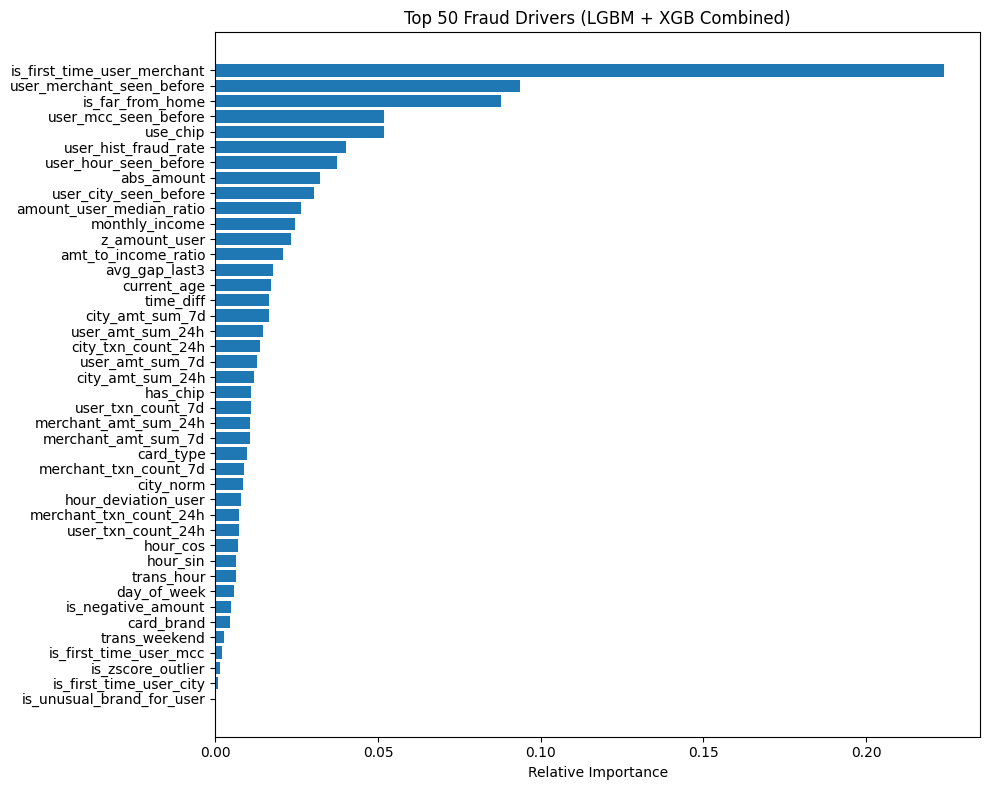

In [77]:
import matplotlib.pyplot as plt

top_50 = importance_df.head(50)

plt.figure(figsize=(10, 8))
plt.barh(
    top_50['feature'][::-1],
    top_50['combined_importance'][::-1]
)
plt.xlabel('Relative Importance')
plt.title('Top 50 Fraud Drivers (LGBM + XGB Combined)')
plt.tight_layout()
plt.show()

In [78]:
print("Top 60 Fraud Drivers:")
print(importance_df.head(60).to_string(index=False))

Top 60 Fraud Drivers:
                    feature  LGBM_importance  XGB_importance  combined_importance
is_first_time_user_merchant         0.003175        0.444563             0.223869
  user_merchant_seen_before         0.068624        0.118782             0.093703
           is_far_from_home         0.008201        0.167320             0.087761
       user_mcc_seen_before         0.084392        0.019430             0.051911
                   use_chip         0.026402        0.077054             0.051728
       user_hist_fraud_rate         0.065926        0.014160             0.040043
      user_hour_seen_before         0.066984        0.007770             0.037377
                 abs_amount         0.056561        0.007705             0.032133
      user_city_seen_before         0.053333        0.007105             0.030219
   amount_user_median_ratio         0.045291        0.007471             0.026381
             monthly_income         0.045238        0.003899             0.0

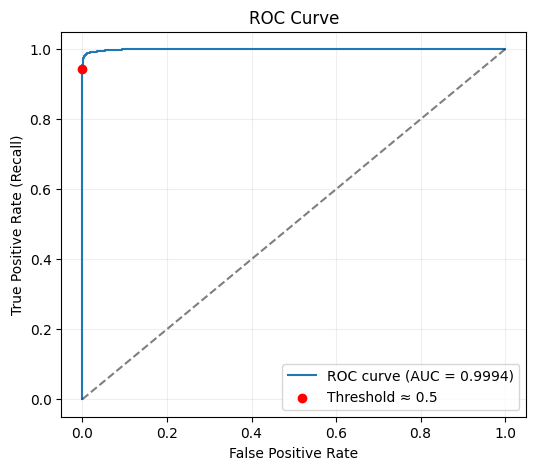

In [85]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve

fpr, tpr, thr_roc = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# find the point on the ROC curve closest to threshold=0.5
# (not exact match because thresholds are derived from scores)
idx_05 = np.argmin(np.abs(thr_roc - 0.9972))

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.scatter(fpr[idx_05], tpr[idx_05], color="red", zorder=3, label="Threshold ≈ 0.5")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


In [ ]:
import joblib

joblib.dump(stacked_model, "fraud_stacking_model.pkl")
print("Model exported successfully!")

NameError: name 'stacked_model' is not defined

In [ ]:
joblib.dump(encoder, "encoder.pkl")
joblib.dump(feature_engineer_object, "feature_pipeline.pkl")

In [86]:
trans_final.to_csv("trans_final.csv", index=False)

In [ ]:
df.to_csv("output.csv", index=False)